# Flow Matching: 8 Gaussians → Double Moon

Trains and visualizes five flow matching methods:

1. **OT-CFM** — linear paths, Euclidean OT coupling
2. **OT-Harmonic ω=0.01** — sinusoidal paths (nearly straight), harmonic OT coupling
3. **OT-Harmonic ω=1** — curved sinusoidal paths, harmonic OT coupling
4. **OT-Harmonic ω=π/2** — quarter-circle paths, harmonic OT coupling
5. **OT-Stochastic Interpolant** — cosine interpolation, Euclidean OT coupling

In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchdyn
from torchdyn.core import NeuralODE

from torchcfm.conditional_flow_matching import (
    ExactOptimalTransportConditionalFlowMatcher,
    ExactOptimalTransportHarmonicConditionalFlowMatcher,
    VariancePreservingConditionalFlowMatcher,
)
from torchcfm.models.models import MLP
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def plot_traj(traj, n=2000):
    plt.figure(figsize=(6, 6))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.2, alpha=0.2, c="olive")
    plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")
    plt.axis("off")
    plt.show()

### OT-CFM

5000: loss 0.120 time 63.63
10000: loss 0.094 time 63.27
15000: loss 0.143 time 61.82
20000: loss 0.072 time 61.74


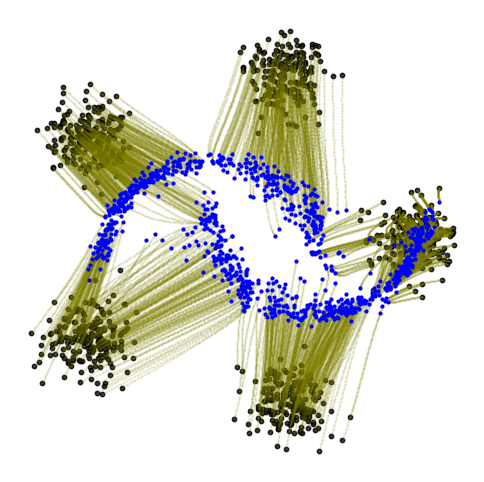

CPU times: user 3min 59s, sys: 14.1 s, total: 4min 13s
Wall time: 4min 12s


In [2]:
%%time
sigma = 0.0
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/otcfm.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

### OT-Harmonic ω=0.01

5000: loss 0.274 time 61.99
10000: loss 0.117 time 65.56
15000: loss 0.144 time 62.81
20000: loss 0.089 time 62.40


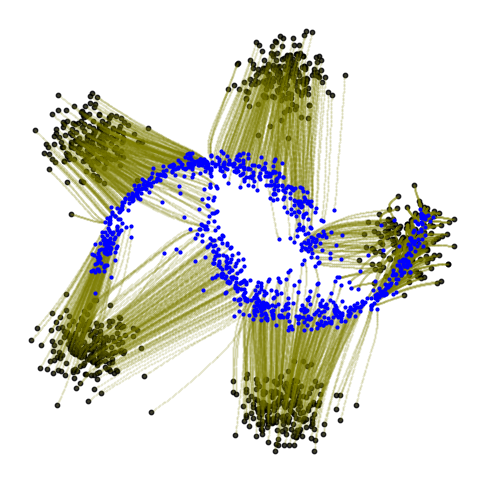

CPU times: user 3min 59s, sys: 17.6 s, total: 4min 16s
Wall time: 4min 15s


In [3]:
%%time
sigma = 0.0
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=0.01)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_w001.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

### OT-Harmonic ω=1

5000: loss 0.199 time 61.10
10000: loss 0.120 time 59.48
15000: loss 0.240 time 60.66
20000: loss 0.158 time 59.96


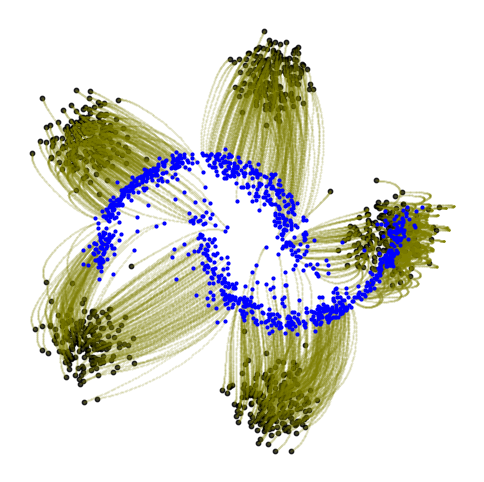

CPU times: user 3min 51s, sys: 15.6 s, total: 4min 6s
Wall time: 4min 3s


In [4]:
%%time
sigma = 0.0
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=1.0)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_w1.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

### OT-Harmonic ω=π/2

5000: loss 0.485 time 60.05
10000: loss 0.208 time 60.04
15000: loss 0.357 time 61.80
20000: loss 0.171 time 61.26


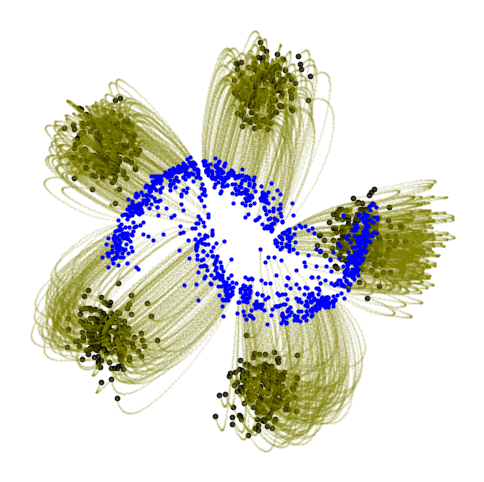

CPU times: user 3min 52s, sys: 15.9 s, total: 4min 8s
Wall time: 4min 5s


In [5]:
%%time
sigma = 0.0
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=math.pi / 2)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_wpi2.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

### OT-Stochastic Interpolant

5000: loss 0.311 time 65.06
10000: loss 0.235 time 64.63
15000: loss 0.172 time 64.73
20000: loss 0.370 time 64.54


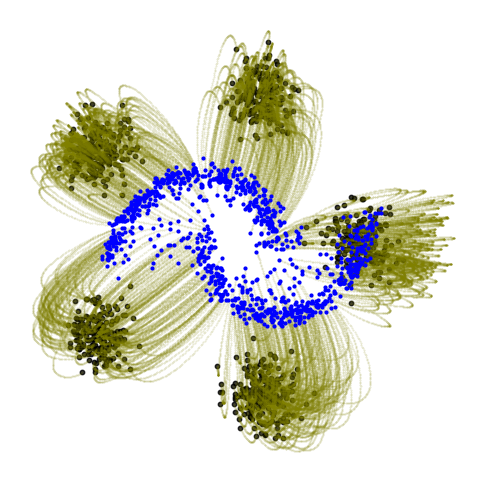

CPU times: user 3min 57s, sys: 27.1 s, total: 4min 24s
Wall time: 4min 21s


In [6]:
%%time
sigma = 0.0
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = VariancePreservingConditionalFlowMatcher(sigma=sigma)
ot_sampler = OTPlanSampler(method="exact")

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)
    x0, x1 = ot_sampler.sample_plan(x0, x1)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_stochastic_interpolant.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())